In [1]:
# Standard Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pyarrow

# Tiingo API
import tiingo
from tiingo import TiingoClient

# Web Requests and Querying
import requests
import  json
import os
import pandas_datareader.data as web
#from aquarel import load_theme

from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file

True

In [2]:
# Initialize Tiingo Client
config = {
    'session': True,
    'api_key': os.getenv("TIINGO_API_KEY")
}

client = TiingoClient(config)

In [3]:
# Tiingo's list of stock tickers
tickers = client.list_stock_tickers()

In [4]:
# Fetch historical price data for SPY

if os.path.exists('data/spy_daily.parquet'):
    spy_weekly_df = pd.read_parquet('data/spy_daily.parquet', index='date')
else:
    spy_weekly = client.get_ticker_price("SPY", 
                                         frequency="daily", 
                                         columns='open,low,high,adjClose,volume',
                                         startDate='2015-01-01',
                                     endDate='2025-12-31')

In [6]:
# Convert to DataFrame and set date as index
spy_weekly_df = pd.DataFrame(spy_weekly)

spy_weekly_df['date'] = pd.to_datetime(spy_weekly_df['date'])
spy_weekly_df.set_index('date', inplace=True)

spy_weekly_df.to_parquet('./data/spy_daily.parquet', index=True)

In [7]:
# Calculate returns
    # Percentage returns
spy_weekly_df['ret'] = spy_weekly_df['adjClose'].pct_change()
    # Absolute returns
spy_weekly_df['usd_ret'] = spy_weekly_df['adjClose'].diff()

# Drop NA values
spy_weekly_df.dropna(inplace=True)

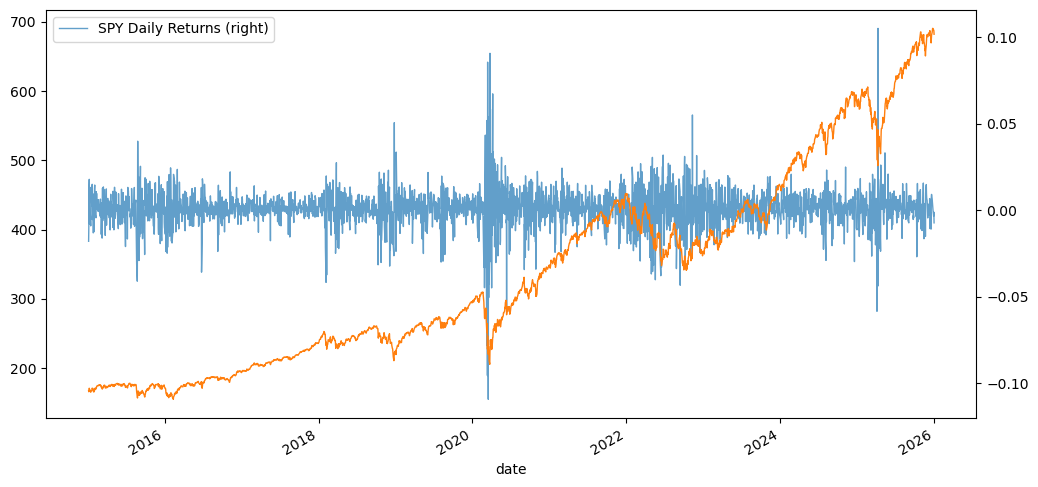

In [8]:
# Plotting the adjusted close prices and returns

fig, ax = plt.subplots(figsize=(12, 6))
ax2 = spy_weekly_df['ret'].plot(ax=ax, label='SPY Daily Returns', secondary_y=True, linewidth=1, alpha=0.7)
spy_weekly_df['adjClose'].plot(ax=ax, label='SPY Daily Closing Prices', linewidth=1)
#spy_weekly_df['usd_ret'].plot(ax=ax, label='SPY Daily Absolute Returns')

ax.set_zorder(ax2.get_zorder()+1)
ax.set_frame_on(False)

plt.legend()
plt.show()

<Axes: title={'center': 'SPY Weekly Returns vs Adjusted Closing Prices'}, xlabel='adjClose', ylabel='ret'>

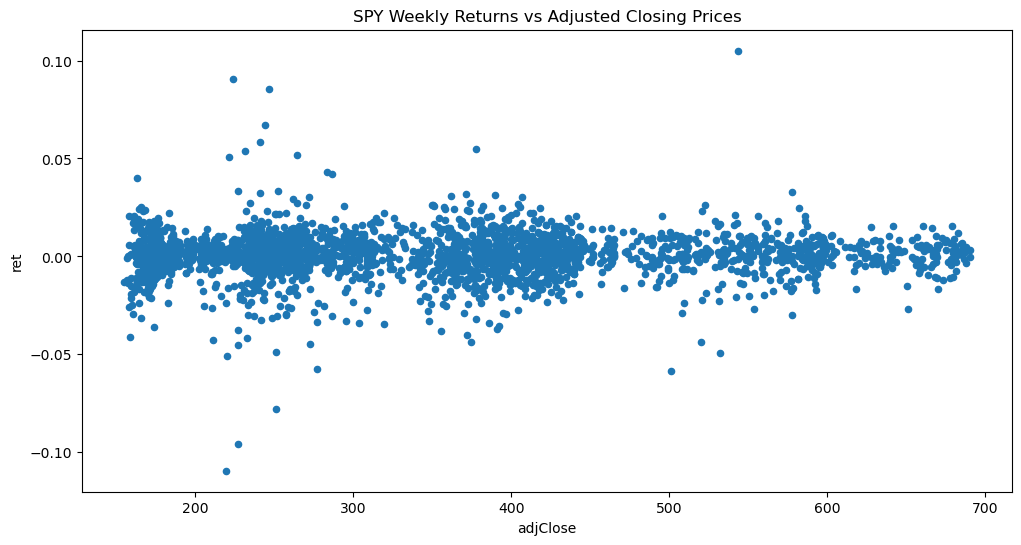

In [9]:
# Scatter plot of returns vs adjusted close prices
fig, ax = plt.subplots(figsize=(12, 6))
spy_weekly_df.plot(x='adjClose',y='ret', kind='scatter', ax=ax, title='SPY Weekly Returns vs Adjusted Closing Prices')

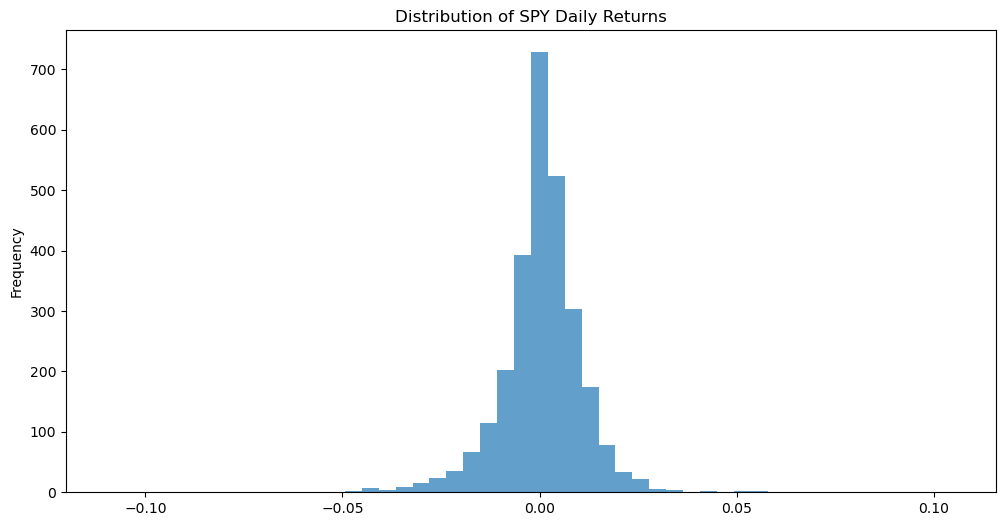

In [10]:
# Distribution plot of returns and binned closing price
fig, ax = plt.subplots(figsize=(12, 6))
spy_weekly_df['ret'].plot(kind='hist', bins=50, alpha=0.7, ax=ax, title='Distribution of SPY Daily Returns')
plt.show()

# GKX Model,Python Implementation (Scikit-Learn)

**OLS**,sklearn.linear_model.LinearRegression

**PLS** (Partial Least Squares),sklearn.cross_decomposition.PLSRegression

**PCR** (Principal Comp Reg),sklearn.decomposition.PCA + LinearRegression

**Elastic Net**,sklearn.linear_model.ElasticNet

**RF** (Random Forest),sklearn.ensemble.RandomForestRegressor

**NN1 - NN5** (Neural Nets),sklearn.neural_network.MLPRegressor (Easiest) or PyTorch (Best)


In [12]:
from sklearn import linear_model, cross_decomposition, decomposition, ensemble, neural_network

In [ ]:
reg = linear_model.LinearRegression()
X = spy_weekly_df[['volume']]
y = spy_weekly_df['ret']